In [1]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
from pathlib import Path
import random

In [ ]:
def fill_corners(gray):
	h, w = gray.shape
	mask = np.zeros((h+2, w+2), dtype=np.uint8)
	corners = [(0, 0), (0, h - 1), (w - 1, 0), (w - 1, h - 1)]
	for corner_seed in corners:
		# Low and high brightness tolerance (e.g., 5-unit tolerance in each channel)
		lo_diff = (0, 0, 0)
		up_diff = (0, 0, 0)

		# Perform the flood fill
		# The function modifies the 'img' array in-place
		black_color = (0,0,0)
		cv.floodFill(
			gray, 
			mask, 
			corner_seed, 
			black_color, 
			loDiff=lo_diff, 
			upDiff=up_diff
		)
	return gray

def binary_cluster_calc_mean(img):
	y, x = np.where(img == 255)
	mean_coo = (int(np.mean(x)), int(np.mean(y)))

	h, w = img.shape
	middle_coo = (w/2, h/2)
	return mean_coo, middle_coo

def simple_segmentation(img, cls):
	corner_filled = fill_corners(img)

	# start segmentation
	threshold_type = cv.THRESH_BINARY
	threshold_type += cv.THRESH_OTSU

	_, thresh = cv.threshold(corner_filled,60,255,threshold_type)

	denoised = cv.medianBlur(thresh, 5)

	return thresh, denoised


def move2middle(img, segment): 
	mean_coo, middle_coo = binary_cluster_calc_mean(segment)
	translation_vector = (int(middle_coo[0] - mean_coo[0]), int(middle_coo[1] - mean_coo[1]))

	translation_matrix = np.float32([
		[1, 0, translation_vector[0]],
		[0, 1, translation_vector[1]]
	])

	h, w, _ = img.shape
	white_color = (255, 255, 255)
	translated_img = cv.warpAffine(
		img, 
		translation_matrix, 
		(w, h),
		borderMode=cv.BORDER_CONSTANT, # Tells OpenCV to use a constant color
		borderValue=white_color          # Specifies the constant color (White)
	)
	return translated_img, mean_coo, middle_coo

def cvreadimg(path: Path):
	img = cv.imread(str(path))
	assert img is not None, "file could not be read, check with os.path.exists()"
	return img

def mvimg2middle(path: Path):
	img = cvreadimg(path)
	cls = path.parent.name.split("_")[0]
	gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

	gray_contrasted = cv.convertScaleAbs(gray, alpha=1.5, beta=0)

	thresh, denoised = simple_segmentation(gray_contrasted, cls)
	translated_img, mean_coo, middle_coo = move2middle(img, denoised)
	return (
		img,
		gray, 
		gray_contrasted,
		thresh, 
		denoised, 
		translated_img, 
		mean_coo, 
		middle_coo,
	)

def plot(ax, path: Path):
	(
		img,
		gray, 
		gray_contrasted,
		thresh, 
		denoised, 
		translated_img, 
		mean_coo, 
		middle_coo,
	) = mvimg2middle(path)

	ax[0].imshow(img, cmap='gray')
	pixel_values = gray.flatten()
	ax[1].hist(
		pixel_values,
		bins=256,         # Use 256 bins for the 256 possible intensity values (0-255)
		range=[0, 256],   # Set the range of the x-axis
		color='gray',
		alpha=0.7
	)
	ax[2].imshow(gray_contrasted, cmap='gray')
	pixel_values_contrasted = gray_contrasted.flatten()
	ax[3].hist(
		pixel_values_contrasted,
		bins=256,         # Use 256 bins for the 256 possible intensity values (0-255)
		range=[0, 256],   # Set the range of the x-axis
		color='gray',
		alpha=0.7
	)
	ax[4].imshow(thresh, cmap='gray')
	ax[5].imshow(denoised, cmap='gray')
	ax[5].plot(mean_coo[0], mean_coo[1], marker='o', color='red', markersize=5)
	ax[5].plot(middle_coo[0], middle_coo[1], marker='o', color='blue', markersize=5)
	ax[6].imshow(translated_img, cmap='gray')

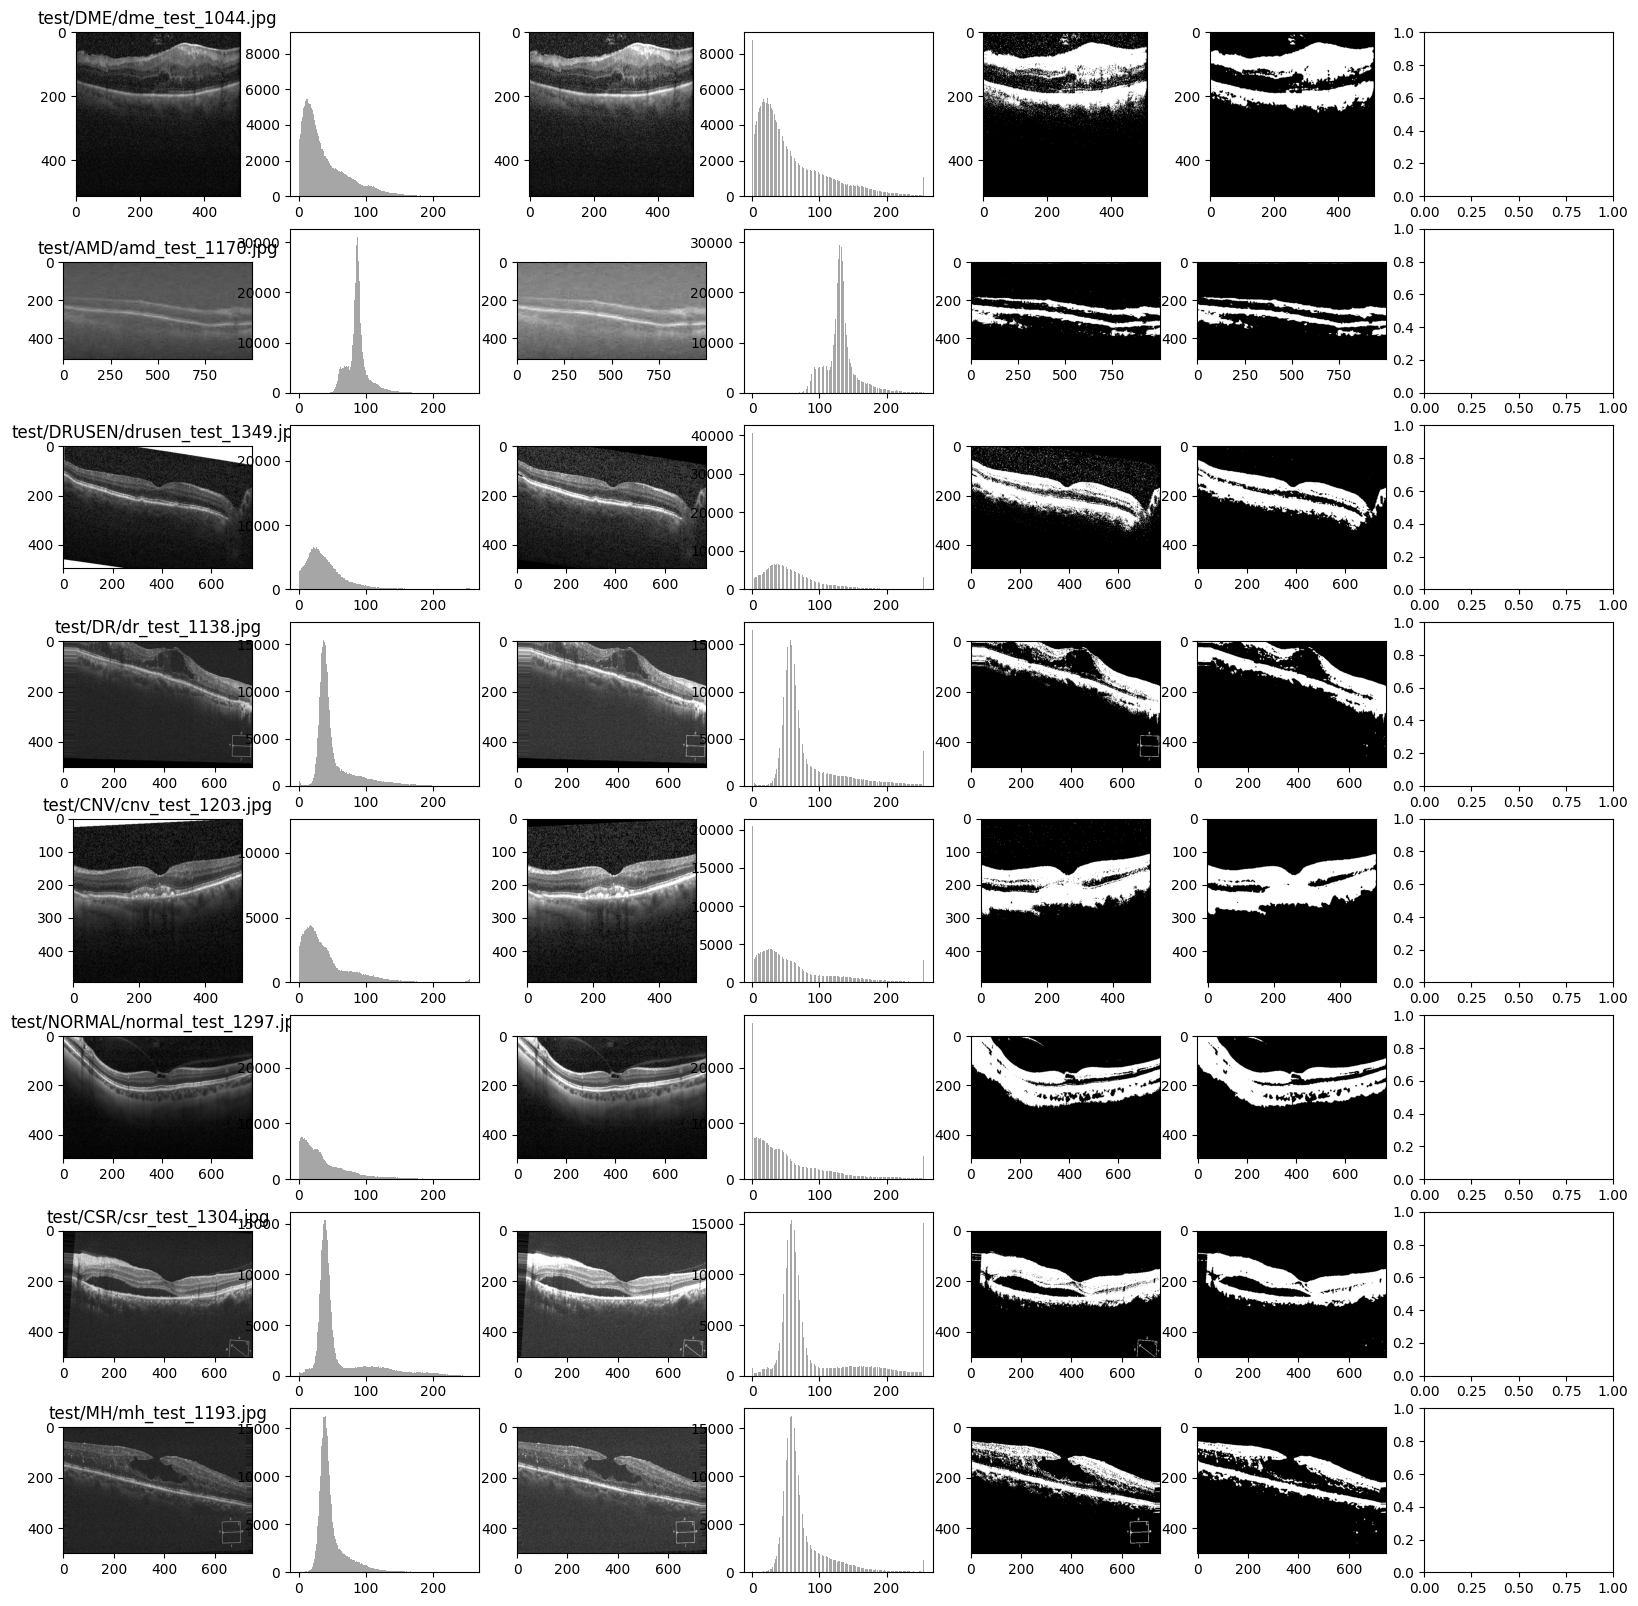

In [3]:
random.seed(42)
classes = ['DME', 'AMD', 'DRUSEN', 'DR', 'CNV', 'NORMAL', 'CSR', 'MH']
file_type = 'test'
fig, ax = plt.subplots(8, 7, figsize=(20,20))
for i, cls in enumerate(classes):
    path = random.choice(list(Path(f'OCTData/{file_type}/{cls}').iterdir()))
    ax[i][0].set_title(f'{file_type}/{cls}/{path.name}')
    plot(ax[i], path)

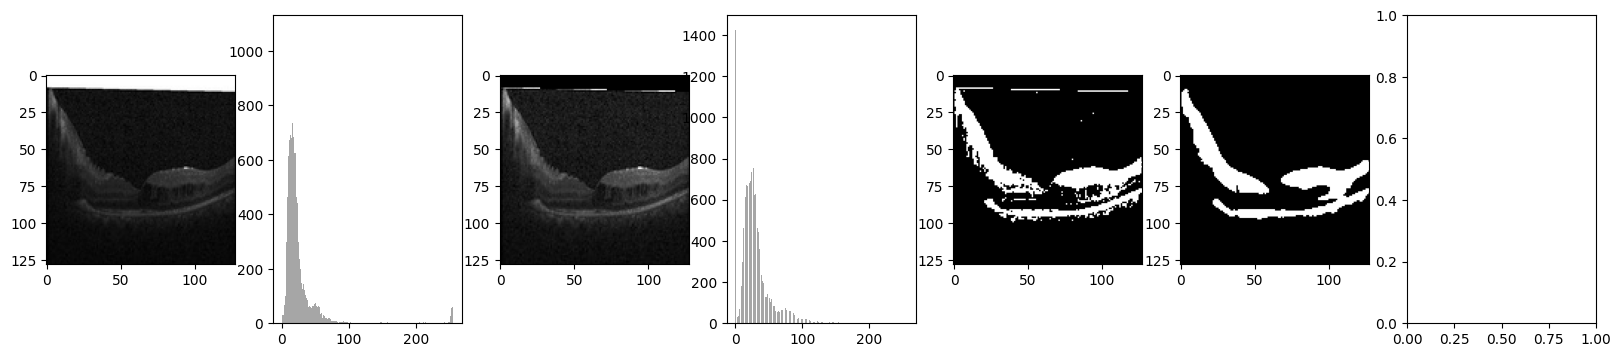

In [4]:
fig, ax = plt.subplots(1, 7, figsize=(20,4))
plot(ax, Path('/home/polyester/Desktop/Programming/OCT-Project/OCTData_resized/test/DME/dme_test_1171.jpg'))